In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_validate
from xgboost import XGBRegressor
from scipy.stats import randint, uniform
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score, make_scorer
from Utils import plot_performance_analysis, shifted_mape
import joblib

In [8]:
X = pd.read_csv('./dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
y_columns = [f'V{i}' for i in range(2,15)] + ['PERD', 'QGEN7'] #V1 ES SIEMPRE 1.0 EN DATASET
Y = pd.read_csv('./dataset/dataset_out.txt', index_col=0).loc[:, y_columns]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]
#NORMALIZACIÓN DE ATRIBUTOS PARA FACILITAR COMPARACIÓN ENTRE MODELOS
normalizer_X = MinMaxScaler(feature_range=(0, 1))
X = pd.DataFrame(normalizer_X.fit_transform(X), columns=X.columns, index=X.index)

In [9]:
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

In [10]:
random_model = XGBRegressor(objective='reg:squarederror', n_jobs=1, random_state=42)
random_grid = {
    'n_estimators': randint(30, 101),
    'max_depth': randint(3, 9),
    'learning_rate': uniform(0.01, 0.2),
    'colsample_bytree': uniform(0.4, 0.5),
}
random_search = RandomizedSearchCV(random_model, random_grid, n_iter=30,
                                   cv=TimeSeriesSplit(n_splits=3), scoring='neg_mean_squared_error',
                                   n_jobs=-1, verbose=2, random_state=42, return_train_score=True)

In [11]:
random_search.fit(x_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': <scipy.stats....001E6AF9EA390>, 'learning_rate': <scipy.stats....001E6AF9EA7D0>, 'max_depth': <scipy.stats....001E6AF9EAD90>, 'n_estimators': <scipy.stats....001E6AF9EB7D0>}"
,n_iter,30
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [12]:
best_random_model = random_search.best_estimator_
print('MSE: ' + str(random_search.best_score_))
random_results = pd.DataFrame(random_search.cv_results_)
random_results.loc[:, ['param_max_depth', 'param_learning_rate', 'param_colsample_bytree',
                       'param_n_estimators', 'mean_test_score']]

MSE: -0.013427586294710636


,param_max_depth,param_learning_rate,param_colsample_bytree,param_n_estimators,mean_test_score
0,5,0.200143,0.587270,90,-0.013428
1,5,0.099167,0.698425,53,-0.032833
2,6,0.021282,0.725444,59,-0.143299
3,7,0.046365,0.506170,62,-0.043027
4,6,0.114951,0.552121,78,-0.017040
5,6,0.089972,0.662387,89,-0.018607
6,8,0.101214,0.583181,80,-0.016099
7,3,0.206646,0.591231,32,-0.046903
8,3,0.146062,0.829970,68,-0.033054
9,8,0.198440,0.406632,38,-0.018795


In [13]:
random_predictions = best_random_model.predict(x_test)
random_MAE = mean_absolute_error(y_test, random_predictions, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
random_MAPE = mean_absolute_percentage_error(y_test + 1.0, random_predictions + 1.0, multioutput='raw_values')
random_R2 = r2_score(y_test, random_predictions, multioutput='raw_values')
random_data_score = np.vstack([random_MAE, random_MAPE, random_R2])
pd.DataFrame(random_data_score, columns=y_columns, index=['MAE', 'MAPE', 'R2'])

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001732,0.001751,0.001739,0.001734,0.001732,0.001753,0.001721,0.001750,0.001729,0.001829,0.001744,0.001390,0.001602,0.300138,0.007436
MAPE,0.000878,0.000888,0.000882,0.000880,0.000879,0.000890,0.000873,0.000888,0.000877,0.000928,0.000885,0.000703,0.000810,0.035169,0.007004
R2,0.972617,0.972494,0.972914,0.973084,0.973222,0.972696,0.973508,0.972797,0.973416,0.970603,0.972849,0.978674,0.972214,0.972779,0.885157


In [14]:
joblib.dump(best_random_model, 'models/MO_XGBoost.pkl')

['modelos/MO_XGBoost.pkl']

In [15]:
random_search.best_params_

{'colsample_bytree': np.float64(0.5872700594236813),
 'learning_rate': np.float64(0.20014286128198325),
 'max_depth': 5,
 'n_estimators': 90}

In [16]:
evaluate_model = XGBRegressor(objective='reg:squarederror', colsample_bytree=0.58, learning_rate=0.2, max_depth=5, n_estimators=90, n_jobs=1, random_state=42)
evaluate_scoring = {
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': make_scorer(shifted_mape, greater_is_better=False),
    'r2': 'r2'
}
evaluate_results = cross_validate(evaluate_model, X, Y, scoring=evaluate_scoring, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results['test_mape'].mean()))
print('R2: ' + str(evaluate_results['test_r2'].mean()))

MSE: 0.015284423716366291
MAE: 0.022820756211876868
MAPE: 0.003664086707683226
R2: 0.9682938814163208


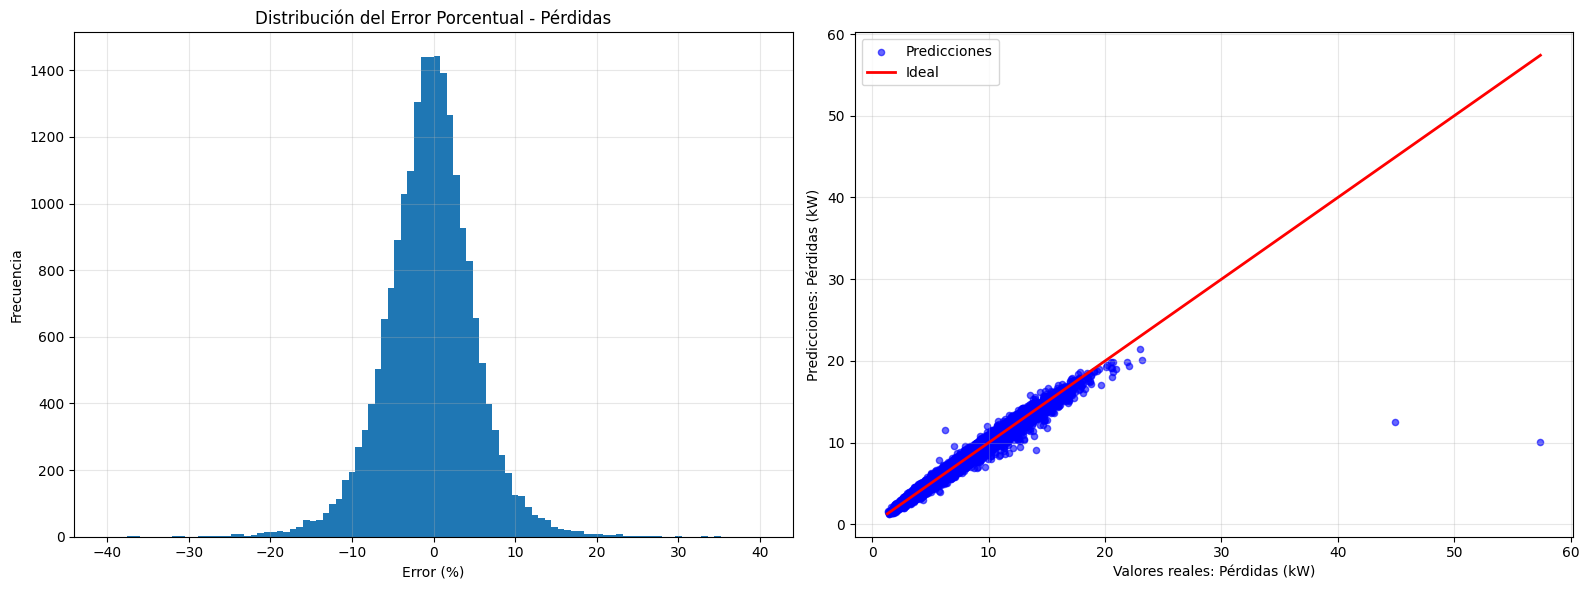

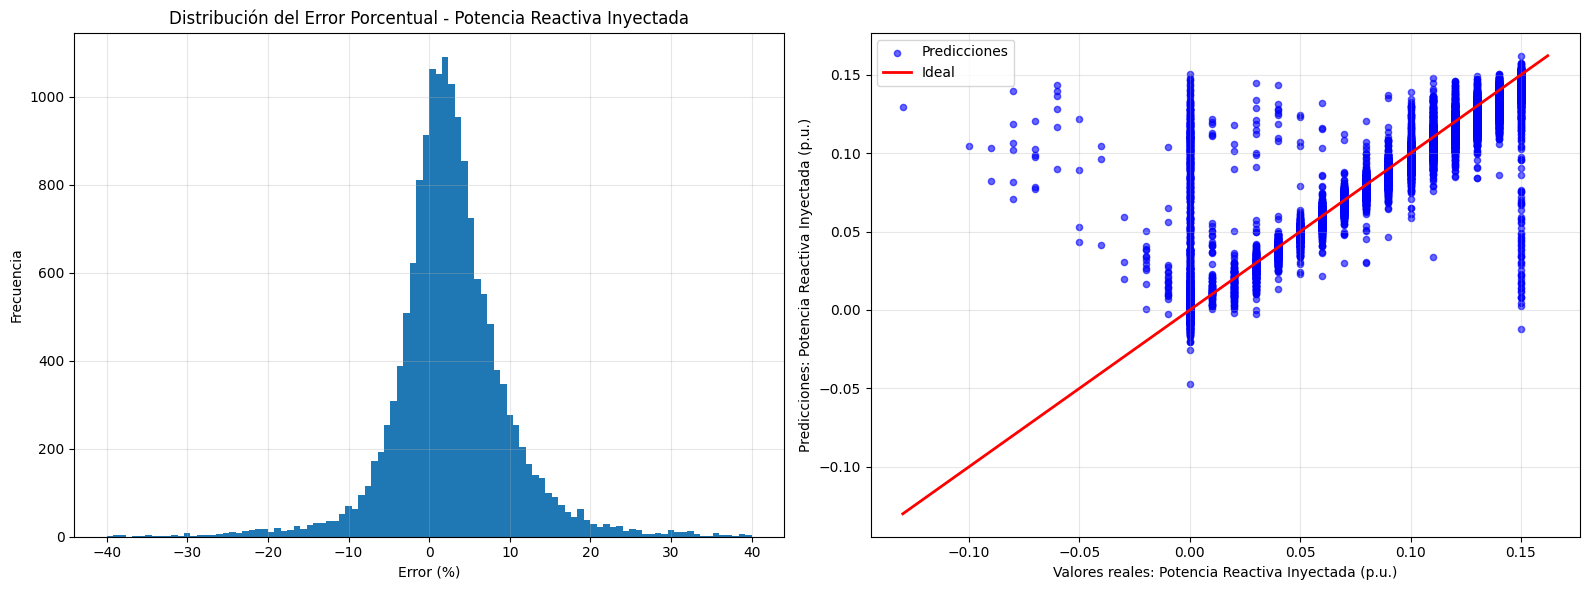

In [17]:
plot_performance_analysis(
    y_test['PERD'],
    random_predictions[:, -2],
    variable_name="Pérdidas",
    unit_label="kW"
)

plot_performance_analysis(
    y_test['QGEN7'],
    random_predictions[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u."
)